<a href="https://colab.research.google.com/github/laalainf-design/laalainf-design/blob/main/covid19_week2_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df= pd.read_csv("/content/covid_19.csv")

In [23]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.dtypes)

            country      continent  population         day  \
0      Saint-Helena         Africa      6115.0  2024-06-30   
1  Falkland-Islands  South-America      3539.0  2024-06-30   
2        Montserrat  North-America      4965.0  2024-06-30   
3  Diamond-Princess            NaN         NaN  2024-06-30   
4      Vatican-City         Europe       799.0  2024-06-30   

                        time  Cases  Recovered  Deaths    Tests  
0  2024-06-30T16:15:16+00:00   2166        2.0     NaN      NaN  
1  2024-06-30T16:15:16+00:00   1930     1930.0     NaN   8632.0  
2  2024-06-30T16:15:16+00:00   1403     1376.0     8.0  17762.0  
3  2024-06-30T16:15:16+00:00    712      699.0    13.0      NaN  
4  2024-06-30T16:15:16+00:00     29       29.0     NaN      NaN  
(238, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    obj

## Dataset overview

**Source:** (/content/covid_19.csv)

This dataset is a COVID-19 snapshot with one row per country, dated 30 June 2024. It records population, total cases, recoveries, deaths and tests. Numeric columns: population, Cases, Recovered, Deaths, Tests. Categorical column: continent. Date columns: day and time. The country column identifies each row.

**Questions I want to answer:**
1. Which continents have the highest cases and deaths per million people?
2. Do countries that test more also report more cases?
3. Which countries have the highest death rate (deaths divided by cases)?

In [24]:
print (df)

              country      continent   population         day  \
0        Saint-Helena         Africa       6115.0  2024-06-30   
1    Falkland-Islands  South-America       3539.0  2024-06-30   
2          Montserrat  North-America       4965.0  2024-06-30   
3    Diamond-Princess            NaN          NaN  2024-06-30   
4        Vatican-City         Europe        799.0  2024-06-30   
..                ...            ...          ...         ...   
233         Argentina  South-America   46010234.0  2024-06-30   
234       Netherlands         Europe   17211447.0  2024-06-30   
235            Mexico  North-America  131562772.0  2024-06-30   
236              Iran           Asia   86022837.0  2024-06-30   
237         Indonesia           Asia  279134505.0  2024-06-30   

                          time     Cases  Recovered    Deaths        Tests  
0    2024-06-30T16:15:16+00:00      2166        2.0       NaN          NaN  
1    2024-06-30T16:15:16+00:00      1930     1930.0       NaN    

In [25]:
df.isna().sum()

,0
country,0
continent,2
population,9
day,0
time,0
Cases,0
Recovered,48
Deaths,5
Tests,25


In [34]:
# Fill missing values in categorical column
# Only 2 continent values are missing, so we fill them with the most frequent value (mode)
df["continent"] = df["continent"].fillna(df["continent"].mode()[0])

# Fill missing numerical values with median
# Median is used because it is less affected by unusually large COVID numbers
df["population"] = df["population"].fillna(df["population"].median())
df["Recovered"] = df["Recovered"].fillna(df["Recovered"].median())
df["Deaths"] = df["Deaths"].fillna(df["Deaths"].median())
df["Tests"] = df["Tests"].fillna(df["Tests"].median())

In [35]:
df.isna().sum()

,0
country,0
continent,0
population,0
day,0
time,0
Cases,0
Recovered,0
Deaths,0
Tests,0


In [36]:
# Requirement 2: handle missing values using fillna()
df_clean = df.copy()

# continent: the 2 missing are cruise ships -> fill with "Unknown"
df_clean["continent"] = df_clean["continent"].fillna("Unknown")

# population: 9 missing (summary rows and ships) -> fill with the median (middle value)
df_clean["population"] = df_clean["population"].fillna(df_clean["population"].median())

# Deaths: only 5 missing, all tiny territories with no reported deaths -> fill with 0
df_clean["Deaths"] = df_clean["Deaths"].fillna(0)

# Recovered: 48 missing -> fill with the median (middle value) so giant countries don't distort it
df_clean["Recovered"] = df_clean["Recovered"].fillna(df_clean["Recovered"].median())

# Tests: 25 missing -> fill with the median for the same reason
df_clean["Tests"] = df_clean["Tests"].fillna(df_clean["Tests"].median())

In [37]:
print(df_clean.shape)
df_clean.isna().sum()

(238, 9)


,0
country,0
continent,0
population,0
day,0
time,0
Cases,0
Recovered,0
Deaths,0
Tests,0


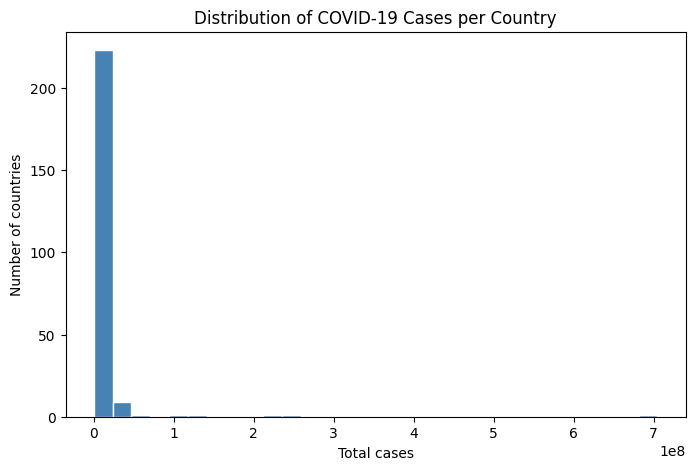

In [38]:
# Requirement 13: histogram with title, axis labels and a custom color
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Cases"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of COVID-19 Cases per Country")
plt.xlabel("Total cases")
plt.ylabel("Number of countries")
plt.show()

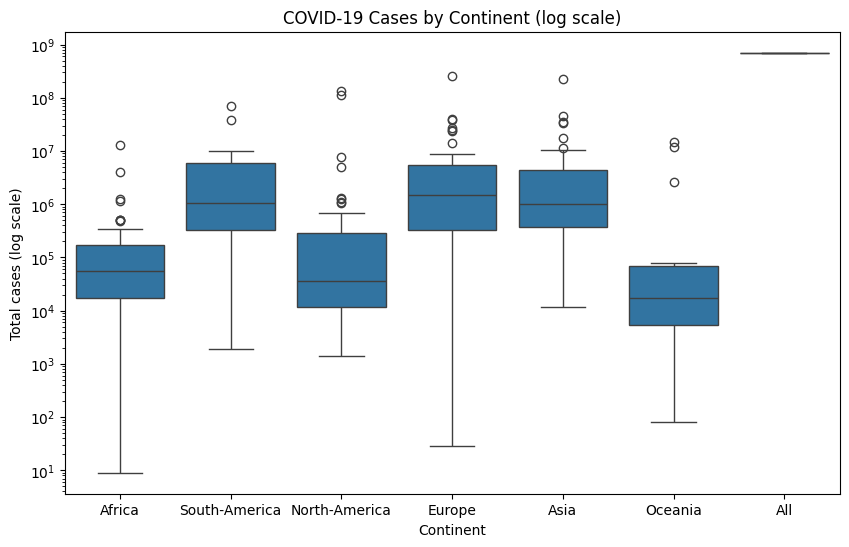

In [39]:
# Requirement 12: boxplot of Cases grouped by continent
plt.figure(figsize=(10, 6))
sns.boxplot(x="continent", y="Cases", data=df_clean)
plt.yscale("log")
plt.title("COVID-19 Cases by Continent (log scale)")
plt.xlabel("Continent")
plt.ylabel("Total cases (log scale)")
plt.show()

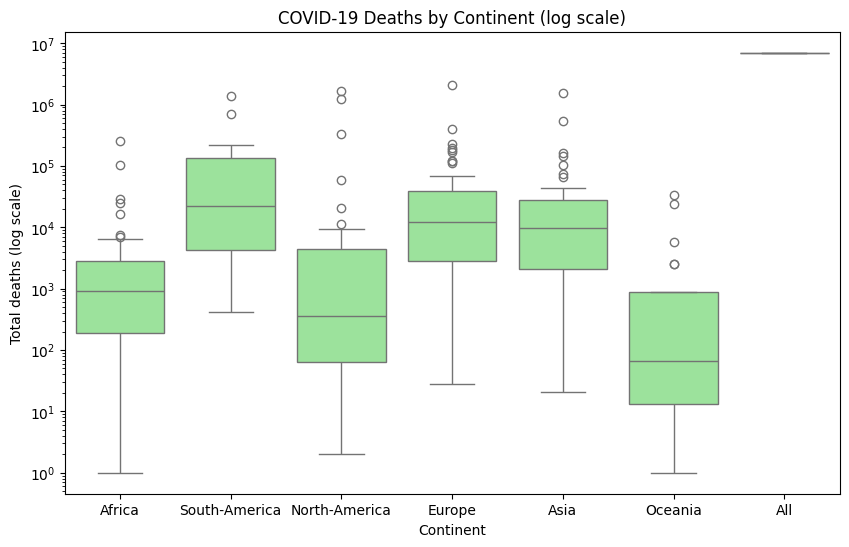

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="continent", y="Deaths", data=df_clean, color="lightgreen")
plt.yscale("log")
plt.title("COVID-19 Deaths by Continent (log scale)")
plt.xlabel("Continent")
plt.ylabel("Total deaths (log scale)")
plt.show()

In [41]:
# Find outliers in Cases using the 1.5 x IQR rule
q1 = df_clean["Cases"].quantile(0.25)   # the 25% mark
q3 = df_clean["Cases"].quantile(0.75)   # the 75% mark
iqr = q3 - q1                           # distance between them
upper_limit = q3 + 1.5 * iqr            # anything above this is unusual

outliers = df_clean[df_clean["Cases"] > upper_limit]

print("Upper limit:", upper_limit)
print("Number of outlier countries:", len(outliers))
outliers[["country", "Cases"]].sort_values("Cases", ascending=False).head(10)

Upper limit: 3872575.0
Number of outlier countries: 45


,country,Cases
218,All,704753890
214,Europe,253406198
213,Asia,221500265
212,North-America,131889132
219,USA,111820082
215,South-America,70200879
220,India,45035393
221,France,40138560
222,Germany,38828995
223,Brazil,38743918


In [45]:
# Requirement 3: filter rows - keep only real countries (2 conditions combined with &)
summary_rows = ["All", "Africa", "Asia", "Europe", "North-America", "South-America", "Oceania"]
ships = ["Diamond-Princess", "MS-Zaandam"]

df_clean = df_clean[(~df_clean["country"].isin(summary_rows)) & (~df_clean["country"].isin(ships))]
df_clean.shape

(229, 9)

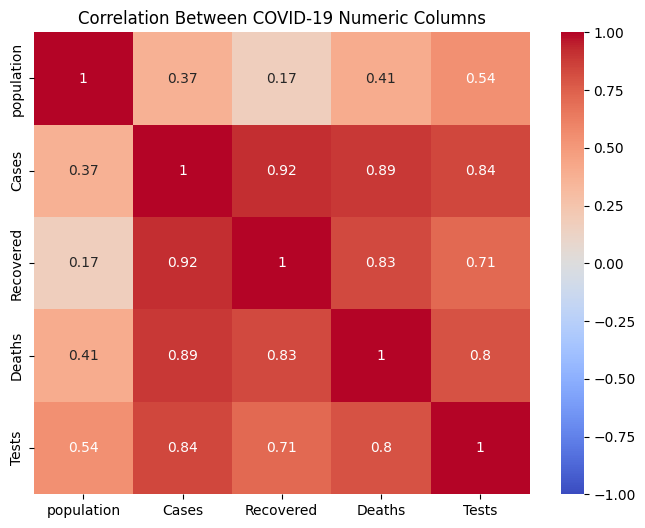

In [46]:
 #correlation heatmap across the numeric columns
numeric_cols = ["population", "Cases", "Recovered", "Deaths", "Tests"]
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between COVID-19 Numeric Columns")
plt.show()

In [43]:
#group by continent and calculate ONE statistic (the mean)
df_clean.groupby("continent")["Cases"].mean()

,Cases
continent,
Africa,4.216815e+05
All,7.047539e+08
Asia,8.686285e+06
Europe,1.034311e+07
North-America,6.594457e+06
Oceania,1.418645e+06
South-America,9.360117e+06


In [44]:
#group by continent and calculate MULTIPLE statistics with .agg()
df_clean.groupby("continent")["Cases"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
continent,,,,
Africa,4.216815e+05,9,12860924,61
All,7.047539e+08,704753890,704753890,1
Asia,8.686285e+06,11945,221500265,51
Europe,1.034311e+07,29,253406198,49
North-America,6.594457e+06,1403,131889132,40
Oceania,1.418645e+06,80,14895771,21
South-America,9.360117e+06,1930,70200879,15


Question 1: which continents have the most cases and deaths per million people?

You should see Oceania (about 342,665) and Europe (about 338,985) at the top for cases per million, and Africa (about 9,142) at the bottom. For deaths per million, South America is highest (about 3,124) and Africa is lowest (about 184).

Question 2: do countries that test more report more cases?

You should see dots rising from bottom left to top right, and the number printed at the end should be about 0.84. Each dot is a country.

Question 3: which countries have the highest death rate (deaths divided by cases)?

You should see Yemen first (about 18%), then Sudan (about 7.9%), Syria (about 5.5%), Somalia and Peru.